# Model

In [1]:
import datetime
print(datetime.datetime.now())

2026-05-21 22:31:08.783790


* A **toy model** is a deliberately simplistic model with many details removed while preserving important and necessary characteristics so that it can be used to explain something concisely.
  * The 'best' model of a subject is exactly the subject itself.
  * However, most of the time, a subject is so complex that we are unable to (or do not know how to) describe it.

* A **machine learning model** can be a mathematical representation of a real-world relationship in data.

* <font color="red">Question: why do we need a model?</font>


## Data Table

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True) # fetch data from network 
ch_df = housing.frame
ch_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


* Table is a straightforward way to present data, and it usually includes
  * $n$ data points
  * each data point is represented by $m$ features, $x_1$ to $x_m$
  * the entire features can be represented as a vector $X$
  * it may have a special column -- a target $y$
* A model $M$ is trying to represent the entire data (including $X$ and $y$).
  * As mentioned, the best way to represent the data is to keep the entire table.
  * However, the number of data points and/or the number of features might be large. It is not efficient to do so.
  * Now, we are trying to find a more concise way to represent the data. Moreover, if there is indeed a concise (mathematical) way to represent the $n$ data points, that means, the data points have some hidden relations (between instances and/or between $X$ and $y$), so that a concise representation is possible.

* We consider a data table that
  * has a **target** $y$
  * all **features** $X$
* A **model** $M: X \rightarrow y$ can be found by using the existing $n$ data points, a.k.a. **training data**.
  * Generally, $X$ and $y$ could be numeric or categorical values.
    * Different types of data and target have different algorithms to create a model.
    * If target $y$ is numeric, the model is called **regression model**.
    * If target $y$ is categorical, the model is called **classification model**.
  * Theoretically, many models can be used to correctly represent the $n$ data points. However, most of the time, we want a concise one and can accept some small errors (it is a trade-off).
    * That means, maybe not all $n$ data points are represented.
    * Maybe $y$ value has an error.
  * As mentioned, there might be a ground-truth function that can generate the training data (from a hidden distribution), $y = f(X)$. These $n$ data points can be viewed as some samples (observations) from the distribution.
  * A model can be viewed as an approximate function to represent the data in this way: $\hat{y} = g(X)$.
    * $\hat{y}$ is the **predicted** value of the model $g()$ given $X$.
    * $g()$ is an approximation of $f()$.

* If a model,
  * has $X$ and $y$, we can learn the relation between $X$ and $y$ by different algorithms. These algorithms belong to **supervised learning**.
  * has only $X$, we can learn the relation between these $n$ data points in $X$. Such algorithms belong to **unsupervised learning**.


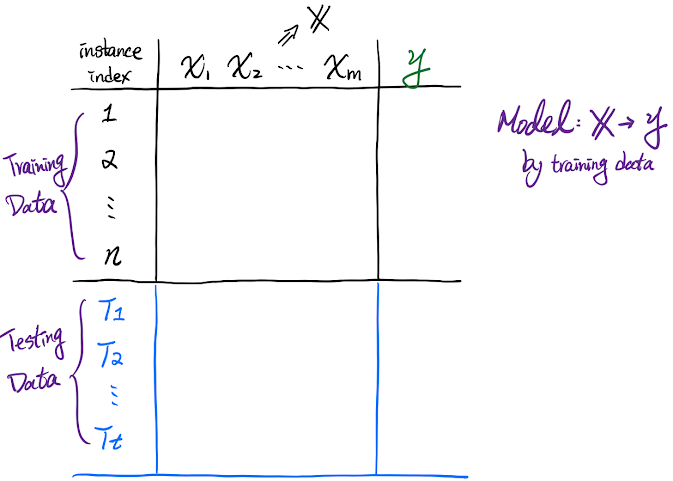

## Linear Regression

Linear regression is a **supervised** learning algorithm, i.e., it can find the relation between $X$ and $y$. Moreover, it is a regression algorithm whose target $y$ is **numeric**. (Note that usually $X$ is numeric as well.)


### Make toy dataset

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Create simple data
n = 20
np.random.seed(0)
x = np.random.rand(n)*4
y = 1.05 * x + np.random.randn(n)/5 - 0.5

pd.DataFrame({'x': x, 'y': y})

,x,y
0,2.195254,2.103833
1,2.860757,2.462764
2,2.411054,2.094220
3,2.179533,1.617690
4,1.694619,0.768752
5,2.583576,2.343479
6,1.750349,1.510754
7,3.567092,3.097014
8,3.854651,4.001335
9,1.533766,0.819581


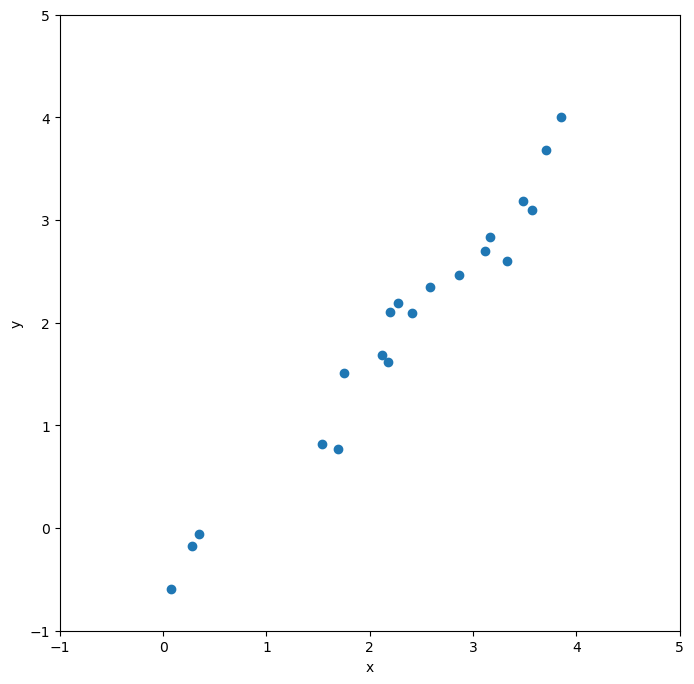

In [5]:
# plot
plt.figure(figsize=(8, 8))
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.show()

### Question about Linear Regression?

* Does the above data look like 'linear'?
* If we do not want to remember the entire data set (although it has only 20 data points), can we use a line to represent the data (i.e., find the relationship between $x$ and $y$)?
* Would a line be appropriate?
* How do we find the 'best' line (i.e., model) to represent the data? Which one (red line or blue line) can best represent the relationship between $x$ and $y$?

### Model and Errors

In [7]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

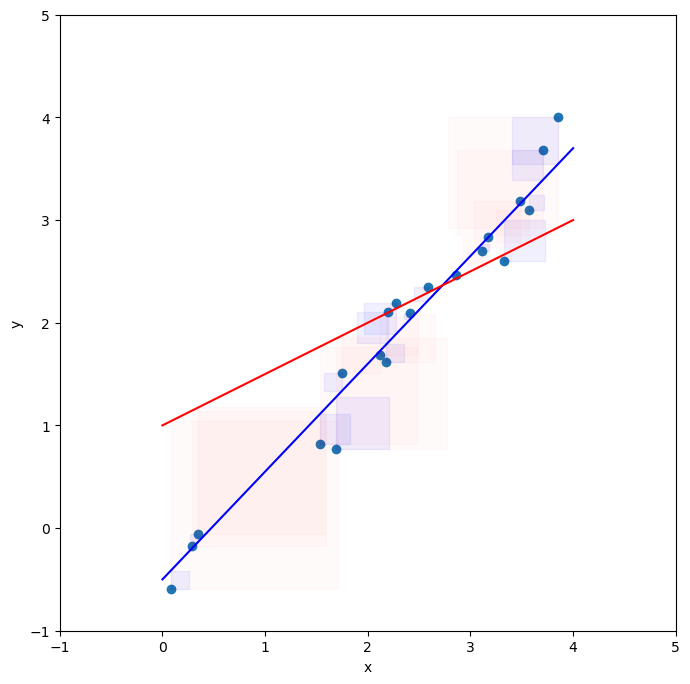

In [8]:
# Errors
fig, ax = plt.subplots(figsize = (8, 8))
plt.scatter(x, y)
plt.plot([0, 4], [-0.5, 3.7], color="blue") # [x0, x1], [y0, y1] y = 1.05*x-0.5
plt.plot([0, 4], [1, 3], color="red") # [x0, x1], [y0, y1] y = 0.5*x+1
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.gca().set_aspect('equal', adjustable='box')

# blue
errorboxes = [Rectangle((i - (j-(a*i+b)), j - (j-(a*i+b))), j-(a*i+b), j-(a*i+b)) if j > (a*i+b) else Rectangle((i,j), a*i+b-j, a*i+b-j ) for i, j, a, b in zip(x, y, [1.05]*n, [-0.5]*n)]
pc = PatchCollection(errorboxes, facecolor='blue', alpha=0.06, edgecolor='blue')
ax.add_collection(pc)

# red
reb = [Rectangle((i - (j-(a*i+b)), j - (j-(a*i+b))), j-(a*i+b), j-(a*i+b)) if j > (a*i+b) else Rectangle((i,j), a*i+b-j, a*i+b-j ) for i, j, a, b in zip(x, y, [0.5]*n, [1.0]*n)]
rpc = PatchCollection(reb, facecolor='red', alpha=0.02, edgecolor='red')
ax.add_collection(rpc)

plt.show()

### MSE (mean square error) and other errors
* MSE = $\frac{1}{n}\sum_{i=1}^{n}{(y_i - \hat{y_i})^{2}}$

  * $\hat{y_i}$ = $g(x_i)$
  * Linear regression model with one feature: $g(x_1)$ = $ax_1+b$
  * General Form: $g(X)$ = $\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3 + ...$, and $\theta$ is the set of all coefficients
  * Or $g(X) = W^T \cdot X$, and $W$ stands for weight vector (generally, b can be included in $W$); $T$ is transpose.

* RMSE = $\sqrt{\text{MSE}}$

* MAE = $\frac{1}{n}\sum_{i=1}^{n}{|y_i - \hat{y_i}|}$

* Which evaluation is better?

### Linear Regression by sklearn

In [9]:
from sklearn.linear_model import LinearRegression

#initantiate the linear regression
linearRegModel = LinearRegression()

# X should look like [[2.195254], [2.860757], ...]
# since X may have more than one features
X = x.reshape(-1, 1)

#fit the model to the training data (learn the coefficients)
linearRegModel.fit(X, y)

print("Intercept is ", linearRegModel.intercept_)

# If multiple features in X, then we get a list of coefficient.
print("coefficient is ", linearRegModel.coef_)

Intercept is  -0.6075418421921326
coefficient is  [1.09674556]


In [10]:
# prediction

predicted_y = linearRegModel.predict(X)
df = pd.DataFrame({'x': x, 'y': y,
                   'y_hat': predicted_y,
                   'y_blu': 1.05 * x -0.5,
                   'y_red': 0.5 * x + 1.0 })

In [11]:
print("MSE_y_hat", sum(np.power(df['y']-df['y_hat'], 2))/n)
print("MSE_y_blu", sum(np.power(df['y']-df['y_blu'], 2))/n)
print("MSE_y_red", sum(np.power(df['y']-df['y_red'], 2))/n)

MSE_y_hat 0.0537001711730305
MSE_y_blu 0.056363264792054876
MSE_y_red 0.5355882998620926


In [12]:
print("MAE_y_hat", sum(np.abs(df['y']-df['y_hat']))/n)
print("MAE_y_blu", sum(np.abs(df['y']-df['y_blu']))/n)
print("MAE_y_red", sum(np.abs(df['y']-df['y_red']))/n)

MAE_y_hat 0.18869548427776175
MAE_y_blu 0.1854476433817208
MAE_y_red 0.5396609777352447


### MAE or MSE

**MSE (Mean Squared Error)**

* Advantages:
  * MSE penalizes large errors more heavily than MAE. This can be important if you are concerned about outliers in your data.
  * MSE is a differentiable function, which makes it easier to use with gradient-based optimization algorithms.
* Disadvantages:
  * MSE is more sensitive to outliers than MAE. This can be a problem if you have a lot of outliers in your data.
  * MSE can be misleading if your data is skewed. This is because MSE gives more weight to larger errors, which can skew the results.

**MAE (Mean Absolute Error)**

* Advantages:
  * MAE is less sensitive to outliers than MSE. This can be important if you have a lot of outliers in your data.
  * MAE is not affected by skewness in the data.
* Disadvantages:
  * MAE does not penalize large errors as heavily as MSE. This can be a problem if you are concerned about outliers in your data.
  * MAE is not a differentiable function (non-smooth at zero), which makes it more difficult to use with gradient-based optimization algorithms.
  * MAE does not penalize large errors, if you are concerned about outliers.

Here are some additional factors to consider when choosing an error metric:

* **Interpretability**: MAE is often easier to interpret than MSE, as it represents the average absolute difference between the predicted and actual values.
* **Robustness**: MAE is more robust to outliers than MSE.
* **Computational Friendly**: MSE is computationally friendly.

### Find $\theta^*$


* Find the minimum value of MSE by differentiation!
  * MSE = $\frac{1}{n}\sum_{i=1}^{n}{(y_i - \hat{y_i})^{2}}$
  * Let $\hat{y_i} = \theta_0 + \theta_1 x_i $ (or $\hat{y} = ax+b$, i.e., linear model)
  * MSE = $\frac{1}{n}\sum_{i=1}^{n}{(y_i - (\theta_0 + \theta_1 x_i))^{2}}$
  * MSE = $\frac{1}{n}\sum_{i=1}^{n}{x_{i}^{2}\theta_{1}^{2} + \theta_{0}^{2} + 2 x_i \theta_1 \theta_0 - 2 x_{i} y_{i} \theta_1 - 2 y_i \theta_0  + y_{i}^{2} }$
  * MSE becomes a two variables ($\theta_0$, $\theta_1$) polynomial function of degree 2.
    * From the training data, we know all $x_i$ and $y_i$.
    * MSE is a 3D surface with a minimal value.


In [86]:
f1 = sum(pow(df['x'], 2))/n
f2 = n/n
f3 = 2.0 * sum(df['x'])/n
f4 = -2.0 * sum(df['x'] * df['y']) / n
f5 = -2.0 * sum(df['y'])/n
f6 = sum(pow(df['y'], 2))/n
print(f1, f2, f3, f4, f5, f6)

6.629363560140185 1.0 4.6524385961807795 -11.714899026158848 -3.8874577035887468 5.296935328404827


MSE = $ 6.63 \theta_{1}^{2} + \theta_{0}^{2} + 4.65 \theta_1 \theta_0 - 11.71 \theta_1 - 3.89\theta_0  +5.30 $

How to find $\theta^*$ so that MSE has minimal value? Hint: MSE is a **convex function**.

### Gradient Descent

In [27]:
# Draw the 3D surface (a, b, mse)

a_range = np.linspace(-2, 4, 22) # change the grid granularity, 22 
b_range = np.linspace(-2, 4, 22) # change the grid granularity, 22
A, B = np.meshgrid(a_range, b_range)

min_z = 1000
Z = []
for a in a_range:
  z_value = []
  for b in b_range:
    this_mse = np.sum(np.power(y - (a*x+b), 2))/len(y)
    z_value.append(this_mse)
    if this_mse < min_z:
      min_z = this_mse
      best_a, best_b = a, b
  Z.append(z_value)

In [81]:
import plotly.graph_objects as go

Z_arr = np.array(Z)

fig_3d = go.Figure(data=[
    go.Surface(x=A, y=B, z=Z_arr, colorscale='Viridis', opacity=0.5),
    go.Scatter3d(
        x=[best_a], y=[best_b], z=[min_z],
        mode='markers', marker=dict(size=4, color='red'),
        name='min_mse',
    ),
])
fig_3d.update_layout(
    scene = dict(
    xaxis_title='a (θ<sub>1</sub>)', 
    yaxis_title='b (θ<sub>0</sub>)', 
    zaxis_title='mse',
))
fig_3d.show()

In [29]:
# answer from above grid
print("The best a, b, and mse on grid are:")
print(best_a, best_b, min_z)

# answer from math
print("\nThe actual a*, b*, and mse* are:")
opt_a = linearRegModel.coef_[0]
opt_b = linearRegModel.intercept_
opt_mse = np.sum(np.power(y - (opt_a * x + opt_b), 2)/len(y))

print(opt_a, opt_b, opt_mse)

The best a, b, and mse on grid are:
1.1428571428571428 -0.8571428571428572 0.07654947775434351

The actual a*, b*, and mse* are:
1.0967455631035568 -0.6075418421921326 0.0537001711730305


You should not brute-force try all ($a$, $b$), i.e., ($\theta_1, \theta_0$), to find the optimal $z$ (i.e., minimal MSE*); the grid search above is for illustration only.

The partial derivative is much quicker to find the minimum value of each dimension.

Using a random pair ($a$, $b$) <u>at time 0</u> as the initial trial point, and of course, the corresponding $z$ is unlikely the optimal MSE*.

However, you can take partial derivatives on the a-axis and b-axis, respectively.

So that we can know that starting from the current ($a$,$b$) <u>at time $t$</u>, which direction on the a-axis and b-axis will lead to a smaller $z$. And <u>at time $t$+1</u>, we can choose a better ($a$, $b$) by considering the direction and make one step ($\gamma$, a.k.a. learning rate) toward the minimal MSE. And so on (many times) to find the minimal MSE* with ($a^*$, $b^*$).

MSE = $\frac{1}{n}\sum_{i=1}^{n}{x_{i}^{2}\theta_{1}^{2} + \theta_{0}^{2} + 2 x_i \theta_1 \theta_0 - 2 x_{i} y_{i} \theta_1 - 2 y_i \theta_0  + y_{i}^{2} }$

$\theta_{i}^{(t+1)} = \theta_{i}^{(t)} - \gamma \frac{\partial \text{MSE}(\theta_{0},\theta_{1})}{\partial \theta_i}$


### Question about Gradient Descent

* Sometimes, MSE is defined as follows. Why?
  * MSE' = $\frac{1}{2n}\sum_{i=1}^{n}{(y_i - \hat{y_i})^{2}}$
* Could GD find the minimum $z$?
* What is $\gamma$ (i.e., learning rate)?
* Is there any other faster way to find the minimum $z$?


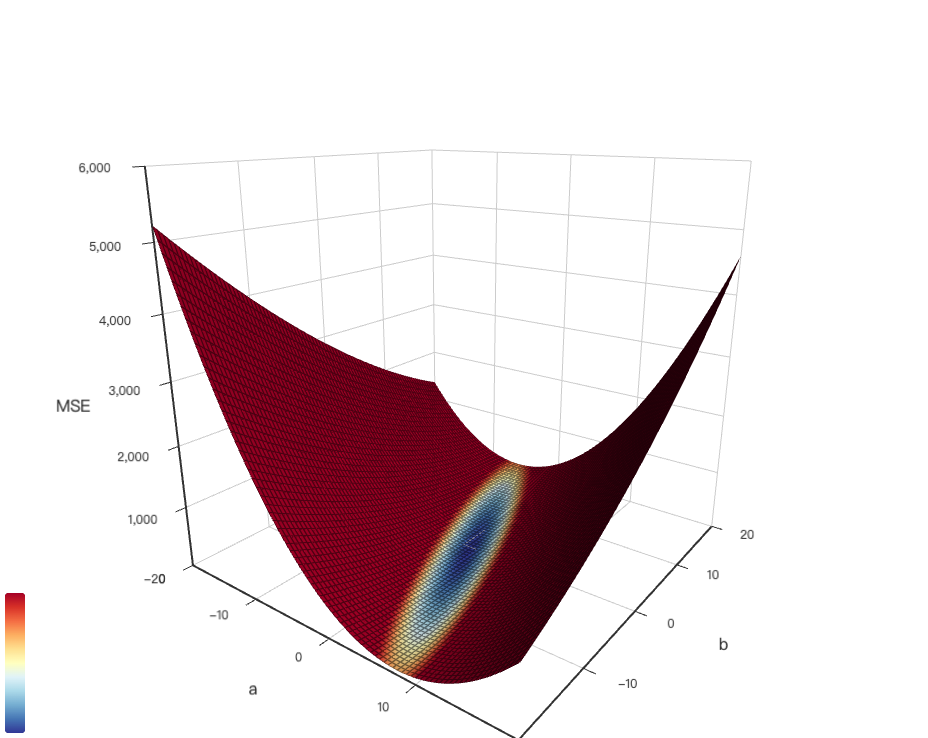

Additional Materials

* [Linear Regression using Python](https://towardsdatascience.com/linear-regression-using-python-b136c91bf0a2)

## Non-linear Data using Linear Regression

In [30]:
import pandas as pd
import seaborn as sns

anscombe_df = sns.load_dataset("anscombe")

In [34]:
print(anscombe_df[anscombe_df.dataset=="I"])

   dataset     x      y
0        I  10.0   8.04
1        I   8.0   6.95
2        I  13.0   7.58
3        I   9.0   8.81
4        I  11.0   8.33
5        I  14.0   9.96
6        I   6.0   7.24
7        I   4.0   4.26
8        I  12.0  10.84
9        I   7.0   4.82
10       I   5.0   5.68


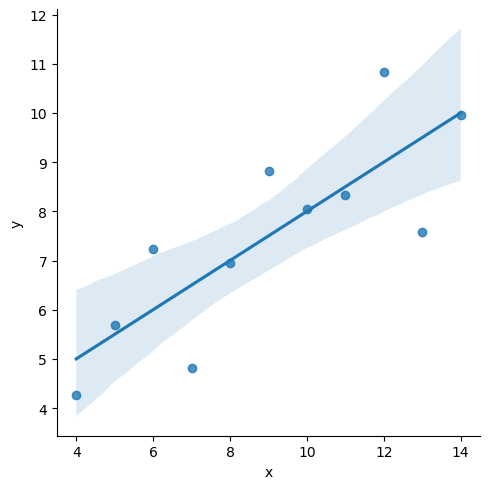

In [37]:
sns.lmplot(x='x', y='y', data=anscombe_df[anscombe_df.dataset == 'I'])
#print("It looks like a liner model which is good enough.")

In [38]:
print(anscombe_df[anscombe_df.dataset=="II"])

   dataset     x     y
11      II  10.0  9.14
12      II   8.0  8.14
13      II  13.0  8.74
14      II   9.0  8.77
15      II  11.0  9.26
16      II  14.0  8.10
17      II   6.0  6.13
18      II   4.0  3.10
19      II  12.0  9.13
20      II   7.0  7.26
21      II   5.0  4.74


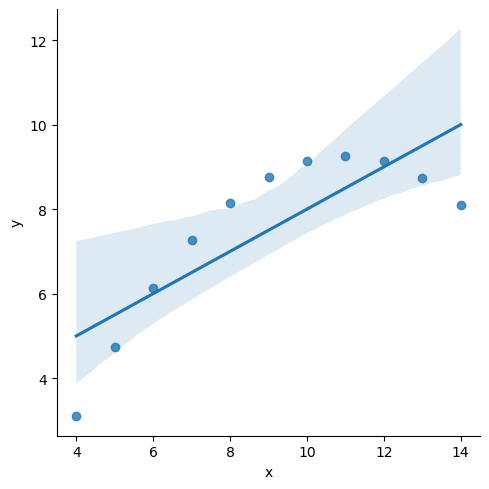

In [40]:
sns.lmplot(x='x', y='y', data=anscombe_df[anscombe_df.dataset == 'II'])
#print("model looks not that good, we need polynomial regression.")

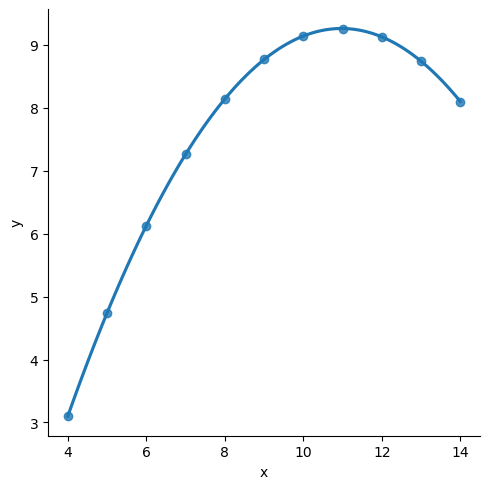

In [41]:
sns.lmplot(x="x", y="y", data=anscombe_df[anscombe_df.dataset == 'II'], order=2)
#print("much better")

In [42]:
print(anscombe_df[anscombe_df.dataset=="III"])

   dataset     x      y
22     III  10.0   7.46
23     III   8.0   6.77
24     III  13.0  12.74
25     III   9.0   7.11
26     III  11.0   7.81
27     III  14.0   8.84
28     III   6.0   6.08
29     III   4.0   5.39
30     III  12.0   8.15
31     III   7.0   6.42
32     III   5.0   5.73


Outliers! It is a big problem!


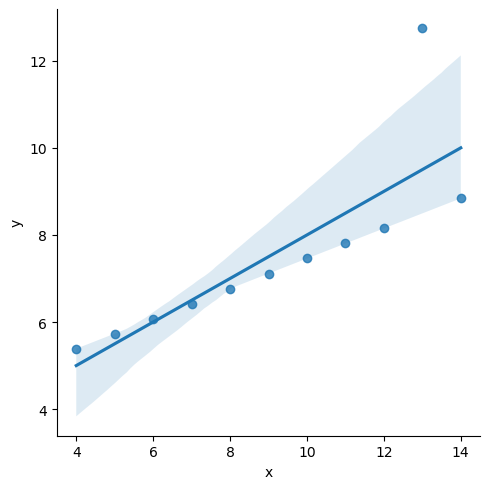

In [43]:
sns.lmplot(x='x', y='y', data=anscombe_df[anscombe_df.dataset == 'III'])
print("Outliers! It is a big problem!" )

However, you should not use some magic functions that you do not know much about them.


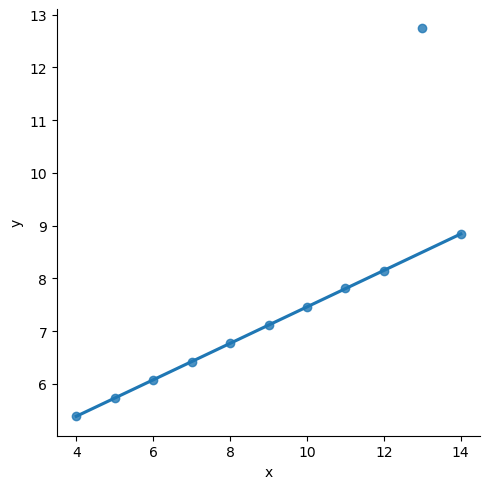

In [44]:
# In the presence of outliers, it can be useful to fit a robust regression,
# which uses a different loss function to downweight relatively large residuals.

sns.lmplot(x="x", y="y", data=anscombe_df[anscombe_df.dataset == 'III'], robust=True, ci = None)
print("However, you should not use some magic functions that you do not know much about them.")

# https://seaborn.pydata.org/generated/seaborn.lmplot.html

Error! It is another big problem!


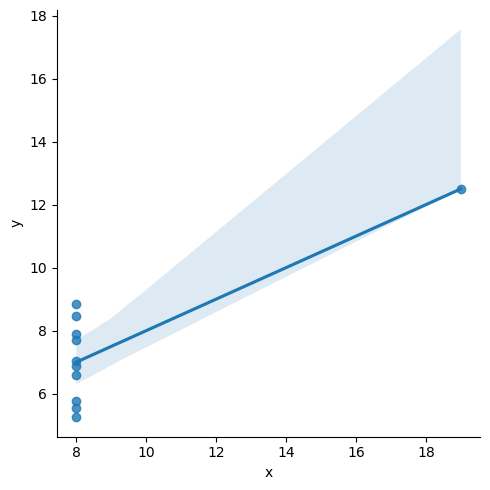

In [46]:
sns.lmplot(x='x', y='y', data=anscombe_df[anscombe_df.dataset == 'IV'])
print("Error! It is another big problem!" )

## Dataset: California Housing

It is a regression problem. All features and target are numeric.

### EDA, Exploratory Data Analysis


In [48]:
from sklearn.model_selection import train_test_split


housing_train_df, housing_test_df = train_test_split(ch_df, test_size=0.2, random_state=42)

In [49]:
housing_train_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,1.030
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,3.821
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,1.726
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,0.934
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,0.965
...,...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96,2.292
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43,0.978
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38,2.221
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96,2.835


In [51]:
housing_test_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000
...,...,...,...,...,...,...,...,...,...
15362,4.6050,16.0,7.002212,1.066372,1351.0,2.988938,33.36,-117.22,2.63300
16623,2.7266,28.0,6.131915,1.256738,1650.0,2.340426,35.36,-120.83,2.66800
18086,9.2298,25.0,7.237676,0.947183,1585.0,2.790493,37.31,-122.05,5.00001
2144,2.7850,36.0,5.289030,0.983122,1227.0,2.588608,36.77,-119.76,0.72300


In [ ]:
# Let "MedHouseVal" be our target.
# See if we can find a linear model to predict the target value.

# take a look at the data
housing_train_df.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       16512 non-null  float64
 1   HouseAge     16512 non-null  float64
 2   AveRooms     16512 non-null  float64
 3   AveBedrms    16512 non-null  float64
 4   Population   16512 non-null  float64
 5   AveOccup     16512 non-null  float64
 6   Latitude     16512 non-null  float64
 7   Longitude    16512 non-null  float64
 8   MedHouseVal  16512 non-null  float64
dtypes: float64(9)
memory usage: 1.3 MB


could you make a comment to all the historgrams?


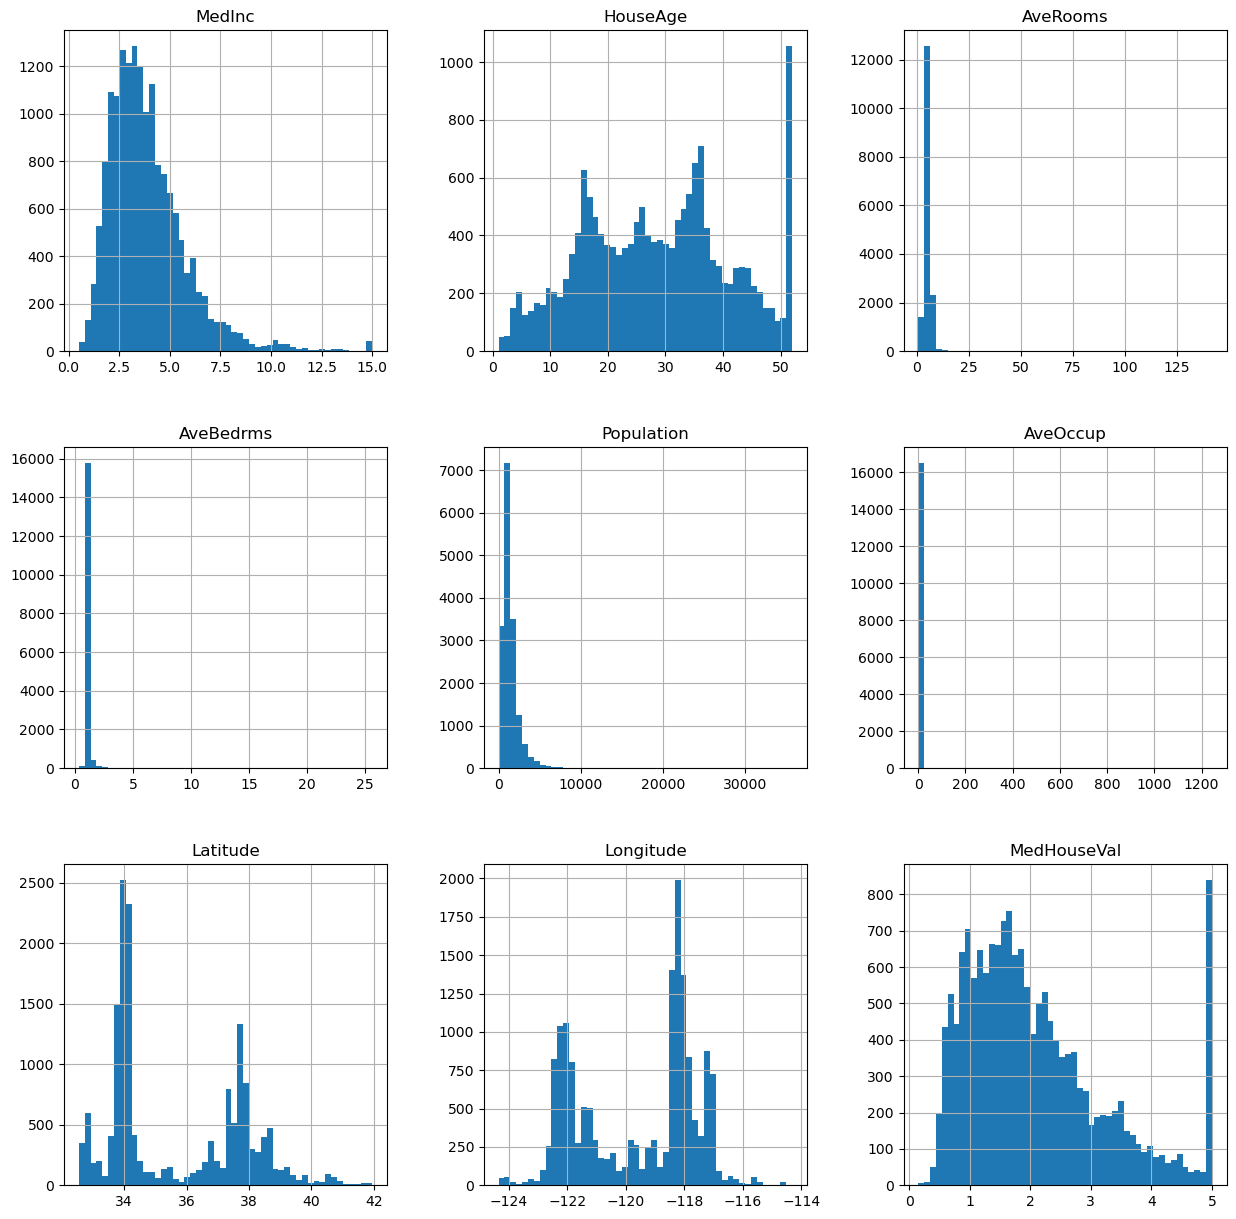

In [53]:
import matplotlib.pyplot as plt

housing_train_df.hist(bins=50, figsize=(15,15))
print("could you make a comment to all the historgrams?")
plt.show()

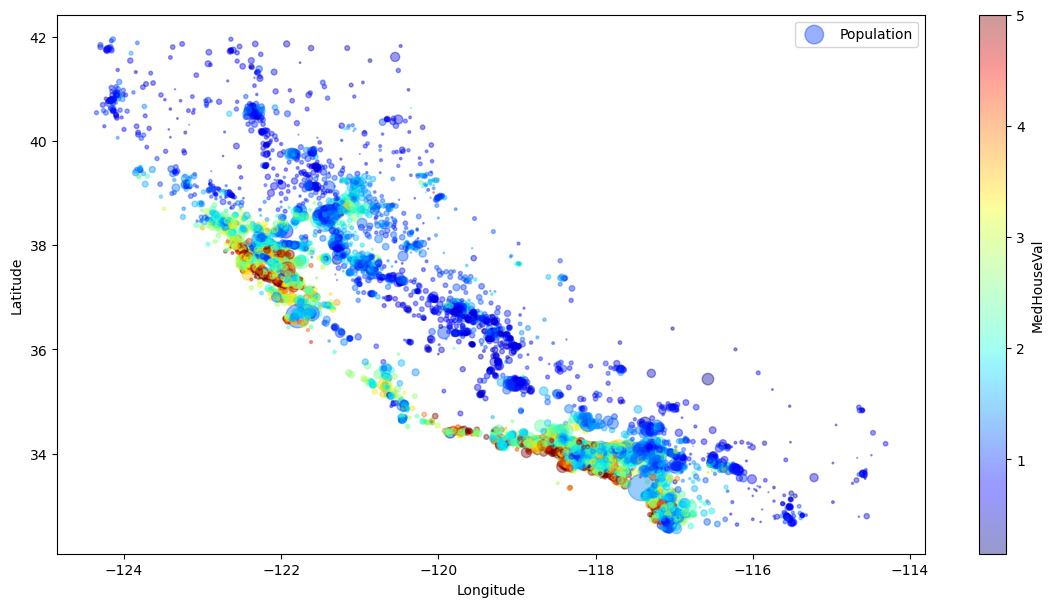

In [ ]:
# s = size; c = color
housing_train_df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.4,
                      s=housing_train_df["Population"]/100, label="Population",
                      c="MedHouseVal", cmap="jet",
                      colorbar=True, figsize=(14,7))
plt.legend()

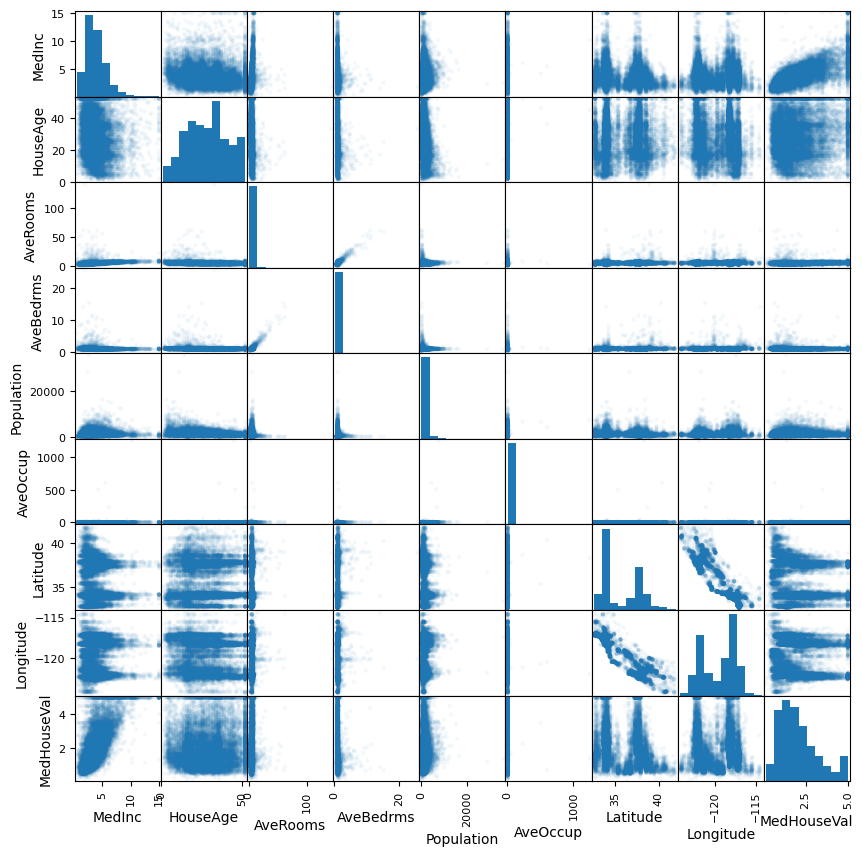

In [57]:
# The scatterplot matrix is a grid of plots of
# multiple variables against each other.
# It shows the relationship of each variable to the others.
# The ones on the diagonal don't fit this pattern.

pd.plotting.scatter_matrix(housing_train_df,
                           alpha=0.05, figsize=(10,10), diagonal='hist')
plt.show()

MedInc looks promising


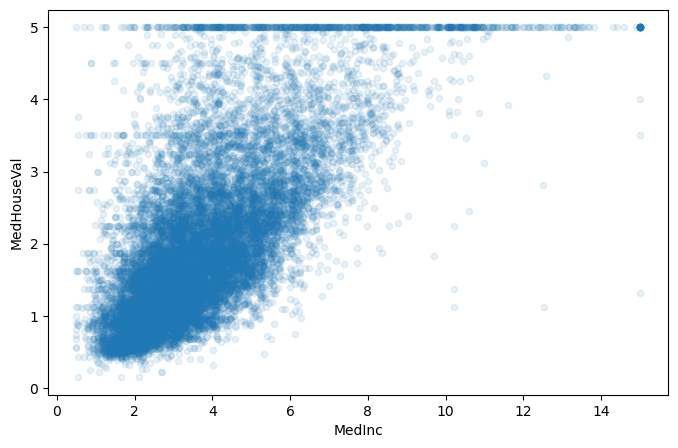

In [58]:
housing_train_df.plot(kind='scatter', x='MedInc', y='MedHouseVal',
                      alpha=0.1, figsize=(8,5))
print("MedInc looks promising")

In [59]:
corr_matrix = housing_train_df.corr()
corr_matrix.style.background_gradient()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.121711,0.336013,-0.072550,0.004122,0.022061,-0.076571,-0.017040,0.690647
HouseAge,-0.121711,1.000000,-0.160892,-0.087983,-0.292283,0.016245,0.005296,-0.101818,0.103706
AveRooms,0.336013,-0.160892,1.000000,0.836163,-0.073733,-0.004922,0.110695,-0.029339,0.158485
AveBedrms,-0.072550,-0.087983,0.836163,1.000000,-0.071267,-0.006035,0.073161,0.016647,-0.051351
Population,0.004122,-0.292283,-0.073733,-0.071267,1.000000,0.072330,-0.102499,0.094276,-0.026032
AveOccup,0.022061,0.016245,-0.004922,-0.006035,0.072330,1.000000,0.005837,-0.000598,-0.022030
Latitude,-0.076571,0.005296,0.110695,0.073161,-0.102499,0.005837,1.000000,-0.924485,-0.142983
Longitude,-0.017040,-0.101818,-0.029339,0.016647,0.094276,-0.000598,-0.924485,1.000000,-0.046349
MedHouseVal,0.690647,0.103706,0.158485,-0.051351,-0.026032,-0.022030,-0.142983,-0.046349,1.000000


In [60]:
corr_matrix['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.690647
AveRooms       0.158485
HouseAge       0.103706
AveOccup      -0.022030
Population    -0.026032
Longitude     -0.046349
AveBedrms     -0.051351
Latitude      -0.142983
Name: MedHouseVal, dtype: float64

### Linear Regression using sklearn

In [36]:
# Again, see the first figure. We need prepare four data blocks
# for learning the model parameters.

# Ususlly, we do not implelemt algorithms on our own.
# There exists well-implemented libraries.
# However, again, you should read API documents before using them.

In [62]:
X_train = housing_train_df.drop(['MedHouseVal'], axis=1)
y_train = housing_train_df['MedHouseVal']

X_test = housing_test_df.drop(['MedHouseVal'], axis=1)
y_test = housing_test_df['MedHouseVal']

In [63]:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
from sklearn.linear_model import LinearRegression

#initantiate the linear regression
model = LinearRegression()

#fit the model to the training data (learn the coefficients)
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
# print the intercept and coefficients
print("Intercept is ", model.intercept_)
print("coefficients  is ", model.coef_)


# print with feature name
print()
print("MedHouseVal = ")
for c,f in zip(model.coef_, X_train.columns):
  print(' {0:+} * {1}'.format(c, f))
print("", model.intercept_)

Intercept is  -37.0232777060643
coefficients  is  [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]

MedHouseVal = 
 +0.4486749096657186 * MedInc
 +0.009724257517905621 * HouseAge
 -0.12332334282795969 * AveRooms
 +0.7831449067929686 * AveBedrms
 -2.029620580108682e-06 * Population
 -0.0035263184871343234 * AveOccup
 -0.41979248658835766 * Latitude
 -0.4337080649639879 * Longitude
 -37.0232777060643


* Does the above formula make sense?

* Why do we believe the real-world data is related
and can be modeled?

* Do you believe this world is linear?

In [68]:
# using the coefficients find by the training data
# to predict the target values of the testing data
y_pred = model.predict(X_test)

In [ ]:
from sklearn import metrics

print("trained model on testing data, mse:", metrics.mean_squared_error(y_test, y_pred))
print("trained model on training data, mse:", metrics.mean_squared_error(y_train, model.predict(X_train)))

print("testing data often has larger (worse) mse, when the model overfits.")

trained model on testing data, mse: 0.5558915986952433
trained model on training data, mse: 0.5179331255246699
testing data often has larger (worse) mse.


In [73]:
# RMSE.
RMSE = pow(np.power(y_test - y_pred, 2).sum()/len(y_test), 0.5)
print(RMSE)

0.7455813830127757


### A trick of Gradient Descent -- Normalization

* Min-Max Scaling: $X_{norm} = \frac{X-X_{min}}{X_{max}-X_{min}}$

* Z-score Normalization: $z = \frac{x-\mu}{\sigma}$
  * $\mu$ is the mean of original data points; $\sigma$ is the std.
  * z: Mapping data points to a distribution whose mean is 0 and std is 1.


To find the optimized z*, the GD (Gradient Descent) works as follows.

MSE = $\frac{1}{n}\sum_{i=1}^{n}{(y_i - (\theta_0 + \theta_1 x_i))^{2}}$

$\theta_{i}^{(t+1)} = \theta_{i}^{(t)} - \gamma \frac{\partial \text{MSE}(\theta)}{\partial \theta_i}$

Look! For each step ($t$), the calculated value of the partial derivative (i.e., $\frac{\partial \text{MSE}(\theta)}{\partial \theta_i}$) on each axis is different, i.e., the length of stride on each axis is different.

In this case, the "speed" of finding the minimum point in each dimension is different. In order to make the MSE convex function to be more like "a bowl" in every dimension, we apply Min-Max Scaling or Z-score Normalization to each dimension.


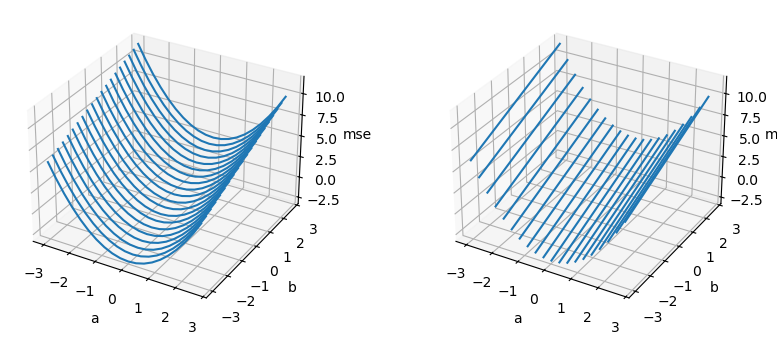

In [83]:
def fun(x, y):
    return x**2 + y

x = y = np.arange(-3.0, 3.0, 0.3)
X, Y = np.meshgrid(x, y)
zs = np.array(fun(np.ravel(X), np.ravel(Y)))
Z = zs.reshape(X.shape)

fig_3d_a = plt.figure(figsize=(10,4))
ax_l = fig_3d_a.add_subplot(121, projection='3d')
ax_r = fig_3d_a.add_subplot(122, projection='3d')

ax_l.plot_wireframe(X, Y, Z, rstride=1, cstride=0)
ax_r.plot_wireframe(X, Y, Z, rstride=0, cstride=1)

ax_l.set_xlabel('a')
ax_l.set_ylabel('b')
ax_l.set_zlabel('mse')

ax_r.set_xlabel('a')
ax_r.set_ylabel('b')
ax_r.set_zlabel('mse')

plt.show()


https://www.sciencemag.org/news/2018/05/ai-researchers-allege-machine-learning-alchemy

Gradient descent relies on trial and error to optimize an algorithm, aiming for minima in a 3D landscape.

ALEXANDER AMINI, DANIELA RUS. MASSACHUSETTS INSTITUTE OF TECHNOLOGY, ADAPTED BY M. ATAROD/SCIENCE